# REFERENCES

- https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/tree/master
- https://bayesiancomputationbook.com/markdown/chp_06.html
- https://www.pymc.io/projects/examples/en/latest/time_series/Forecasting_with_structural_timeseries.html

# SETUP

In [12]:
# Import main libs
from typing import List, Dict
import os
# Avoid PyTensor compiling error on eCryptfs
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["PYTENSOR_FLAGS"] = "base_compiledir=/tmp/pytensor_cache"
from pathlib import Path
import numpy as np
from numpy.random import dirichlet
from numpy.random import multinomial
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import beta
import statsmodels.api as sm
import statsmodels.formula.api as smf
import arviz as az
import preliz as pz
import pymc as pm
import xarray as xr
import pytensor.tensor as pt
import nutpie
az.style.use("preliz-doc")
# az.style.use("bmh")  # Bayesian Methods for Hackers style sheet
# az.style.use("fivethirtyeight")  # Bayesian Methods for Hackers style sheet

In [2]:
# Define constants
PYMC_MODELS_PATH: str = "pymc_models"
Path(PYMC_MODELS_PATH).mkdir(parents=True, exist_ok=True)
SEED: int = 5
DRAWS: int = 4_000
ROOT_PATH = Path.cwd()
print(f"Root path = {ROOT_PATH}")
N_CORES: int = os.cpu_count()
print(f"Number of cores = {N_CORES}")
N_CHAINS: int = int(N_CORES / 4)
print(f"Number of chains = {N_CHAINS}")

Root path = /home/gus-cunha/Projects/bayesian_causal_inference_study
Number of cores = 16
Number of chains = 4


# `A` DATA

- https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/blob/master/Chapter2_MorePyMC/Ch2_MorePyMC_PyMC_current.ipynb

In [3]:
#set constants
p_true = 0.05  # remember, this is unknown.
N = 1500

# sample N Bernoulli random variables from Ber(0.05).
# each random variable has a 0.05 chance of being a 1.
# this is the data-generation step
occurrences = stats.bernoulli.rvs(p_true, size=N)

# Remember: Python treats True == 1, and False == 0
print(occurrences)
print(np.sum(occurrences))

[0 0 0 ... 0 0 0]
70


In [4]:
# Occurrences.mean is equal to n/N.
print("What is the observed frequency in Group A? %.4f" % np.mean(occurrences))
print("Does this equal the true frequency? %s" % (np.mean(occurrences) == p_true))

What is the observed frequency in Group A? 0.0467
Does this equal the true frequency? False


In [5]:
with pm.Model() as model_ab:
    # Priors
    p = pm.Uniform('p', lower=0, upper=1)

    # Likelihood
    p_obs = pm.Bernoulli("p_obs", p=p, observed=occurrences)
    # MCMC sampling
    idata_ab = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=4_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
    )


# Save a checkpoint
idata_ab.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_ab.nc")
)

# Inspect idata
idata_ab

NUTS[nutpie]: [p]


Output()

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 4000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│       Data variables:
│           p        (chain, draw) float64 128kB 0.04315 0.04323 ... 0.056 0.04042
│       Attributes:
│           created_at:                 2026-07-27T12:55:40.391026+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.2149643898010254
│           tuning_steps:               4000
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 4000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 32kB 0 1 2 3 ... 3996 3997 3998 3999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 128kB 2 2 2 1 2 ... 1 2 1 2 2
│           maxdepth_reached          (chain, draw) bool 16kB False False ... False
│           step_size                 (chain, draw) float64 128kB 1.422 1.503 ... 1.388
│           transformation_update_id  (chain, draw) int64 128kB 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 128kB 1.401 1.401 ... 1.399
│           mean_tree_accept          (chain, draw) float64 128kB 0.9106 1.0 ... 1.0
│           ...                        ...
│           fisher_distance           (chain, draw) float64 128kB 0.0002687 ... 0.000...
│           transformation_index      (chain, draw) int64 128kB 3398 3398 ... 3397 3397
│           diverging                 (chain, draw) bool 16kB False False ... False
│           divergence_draw           (chain, draw) uint64 128kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 128kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 128kB nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-07-27T12:55:40.383006+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.1.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-07-27T12:55:40.388470+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /observed_data
        Dimensions:      (p_obs_dim_0: 1500)
        Coordinates:
          * p_obs_dim_0  (p_obs_dim_0) int64 12kB 0 1 2 3 4 ... 1495 1496 1497 1498 1499
        Data variables:
            p_obs        (p_obs_dim_0) int64 12kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
        Attributes:
            created_at:                 2026-07-27T12:55:40.389878+00:00
            creation_library:           ArviZ
            creation_library_version:   1.1.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.0.1
            sample_dims:                []

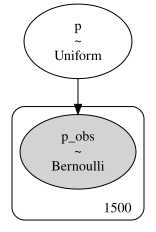

In [6]:
# plot graph
model_ab.to_graphviz()

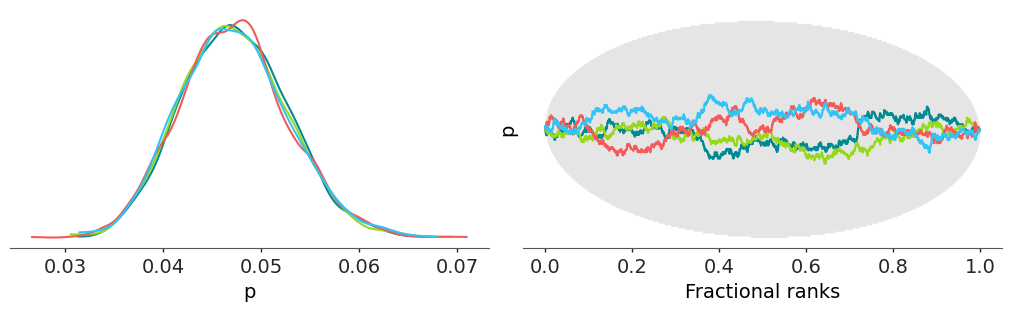

In [7]:
# Plot traces for convergence checking
az.plot_rank_dist(
    dt=idata_ab,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (10, 3)},
);

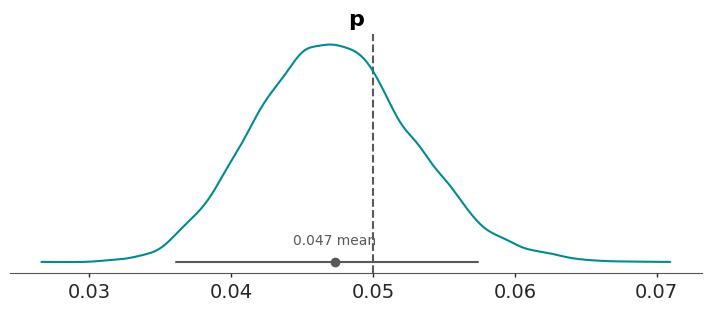

In [8]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_ab,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (7, 3)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "p": p_true,
    },
    orientation="vertical"
);

# `A/B` DATA

- https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/blob/master/Chapter2_MorePyMC/Ch2_MorePyMC_PyMC_current.ipynb

In [9]:
# These two quantities are unknown to us.
true_p_A = 0.05
true_p_B = 0.04

# Notice the unequal sample sizes -- no problem in Bayesian analysis.
N_A = 1500
N_B = 750

# Generate some observations
observations_A = stats.bernoulli.rvs(true_p_A, size=N_A)
observations_B = stats.bernoulli.rvs(true_p_B, size=N_B)
print("Obs from Site A: ", observations_A[:30], "...")
print("\tObs mean from Site A: ", np.mean(observations_A), "...")
print("Obs from Site B: ", observations_B[:30], "...")
print("\tObs mean from Site B: ", np.mean(observations_B), "...")

Obs from Site A:  [0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ...
	Obs mean from Site A:  0.056666666666666664 ...
Obs from Site B:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ...
	Obs mean from Site B:  0.044 ...


In [10]:
with pm.Model() as model_ab:
    # Priors
    p_A = pm.Uniform('p_A', lower=0, upper=1)
    p_B = pm.Uniform('p_B', lower=0, upper=1)    

    # Delta
    # pm.Deterministic
    #   It doesn't change the model's inference at all — it's purely bookkeeping.
    #   It wraps an expression so PyMC (a) gives it a name and (b) stores its value at every posterior draw in the resulting InferenceData.
    #   In other words, it only tells PyMC "track this expression's value at every draw and store it in idata.posterior
    delta_AB = pm.Deterministic(
        name='delta_AB',
        var=p_A - p_B,
    )

    # Likelihood
    p_obs_A = pm.Bernoulli("p_obs_A", p=p_A, observed=observations_A)
    p_obs_B = pm.Bernoulli("p_obs_B", p=p_B, observed=observations_B)

    # MCMC sampling
    idata_ab = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=4_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
    )


# Save a checkpoint
idata_ab.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_ab.nc")
)

# Inspect idata
idata_ab

NUTS[nutpie]: [p_A, p_B]


Output()

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:   (chain: 4, draw: 4000)
│       Coordinates:
│         * chain     (chain) int64 32B 0 1 2 3
│         * draw      (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│       Data variables:
│           p_A       (chain, draw) float64 128kB 0.05098 0.06006 ... 0.05049 0.06349
│           p_B       (chain, draw) float64 128kB 0.04796 0.04942 ... 0.05506 0.03983
│           delta_AB  (chain, draw) float64 128kB 0.003018 0.01065 ... -0.004577 0.02366
│       Attributes:
│           created_at:                 2026-07-27T12:55:51.550374+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.16886281967163086
│           tuning_steps:               4000
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 4000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 32kB 0 1 2 3 ... 3996 3997 3998 3999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 128kB 2 2 2 2 2 ... 1 1 2 1 2
│           maxdepth_reached          (chain, draw) bool 16kB False False ... False
│           step_size                 (chain, draw) float64 128kB 1.077 1.222 ... 1.133
│           transformation_update_id  (chain, draw) int64 128kB 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 128kB 1.192 1.192 ... 1.228
│           mean_tree_accept          (chain, draw) float64 128kB 0.9061 ... 0.7907
│           ...                        ...
│           fisher_distance           (chain, draw) float64 128kB 0.00506 ... 0.002995
│           transformation_index      (chain, draw) int64 128kB 3399 3399 ... 3399 3399
│           diverging                 (chain, draw) bool 16kB False False ... False
│           divergence_draw           (chain, draw) uint64 128kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 128kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 128kB nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-07-27T12:55:51.541809+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.1.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-07-27T12:55:51.547452+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /observed_data
        Dimensions:        (p_obs_A_dim_0: 1500, p_obs_B_dim_0: 750)
        Coordinates:
          * p_obs_A_dim_0  (p_obs_A_dim_0) int64 12kB 0 1 2 3 4 ... 1496 1497 1498 1499
          * p_obs_B_dim_0  (p_obs_B_dim_0) int64 6kB 0 1 2 3 4 5 ... 745 746 747 748 749
        Data variables:
            p_obs_A        (p_obs_A_dim_0) int64 12kB 0 0 0 0 1 0 0 0 ... 0 0 0 0 0 0 0
            p_obs_B        (p_obs_B_dim_0) int64 6kB 0 0 0 0 0 0 0 0 ... 0 0 0 1 0 0 0 0
        Attributes:
            created_at:                 2026-07-27T12:55:51.549065+00:00
            creation_library:           ArviZ
            creation_library_version:   1.1.0
            creation_library_language:  Pyth

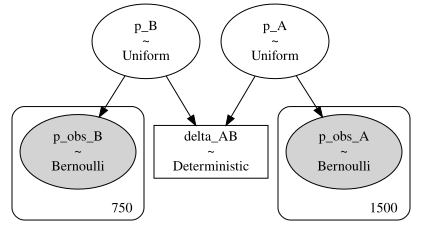

In [11]:
# plot graph
model_ab.to_graphviz()

In [12]:
# Inspect summary
# R hat
#   compute the variance between chains with the variance within chains
#   Ideally = 1, okay if < 1.01
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
# MCSE - Monte Carlo Standard Error
#   Error introduced on MC posterior due to 
#   finite sampling and samples not being truely independent
#   It impact the precision of results
#   The pass criteria to check:
#       mcse_mean / sd (from the same table) below ~5–10%
#       If those all pass (R hat, ESS and MCSE), a U shape MCSE plot is fine as-is
#       the shape is just the normal signature of tail quantiles being harder to pin down.
summary = az.summary(
    data=idata_ab,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='all', fmt='wide', ci_prob=0.95, ci_kind="hdi",
    round_to='auto', skipna=False
)

# Relative MCSE: how big is the sampling error compared to the posterior's own spread?
#   mcse_mean_pct = MCSE of the posterior mean, as a % of the posterior SD.
#       Rule of thumb: < 5–10% is fine; 
#       higher means you'd need more draws to trust the reported mean/HDI to that many significant digits.
#   mcse_sd_pct = same idea for the SD estimate.
summary["mcse_mean_pct"] = summary["mcse_mean"].astype(float) / summary["sd"].astype(float)
summary["mcse_sd_pct"]   = summary["mcse_sd"].astype(float)   / summary["sd"].astype(float)
summary = summary.astype("float")
summary

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,mcse_mean_pct,mcse_sd_pct
p_A,0.05728,0.00603,0.0460,0.070,15510.0,11189.0,1.0,0.000049,0.000035,0.008126,0.005804
p_B,0.04520,0.00756,0.0320,0.061,15574.0,10946.0,1.0,0.000060,0.000044,0.007937,0.005820
delta_AB,0.01210,0.00970,-0.0071,0.031,15563.0,11670.0,1.0,0.000078,0.000056,0.008041,0.005773


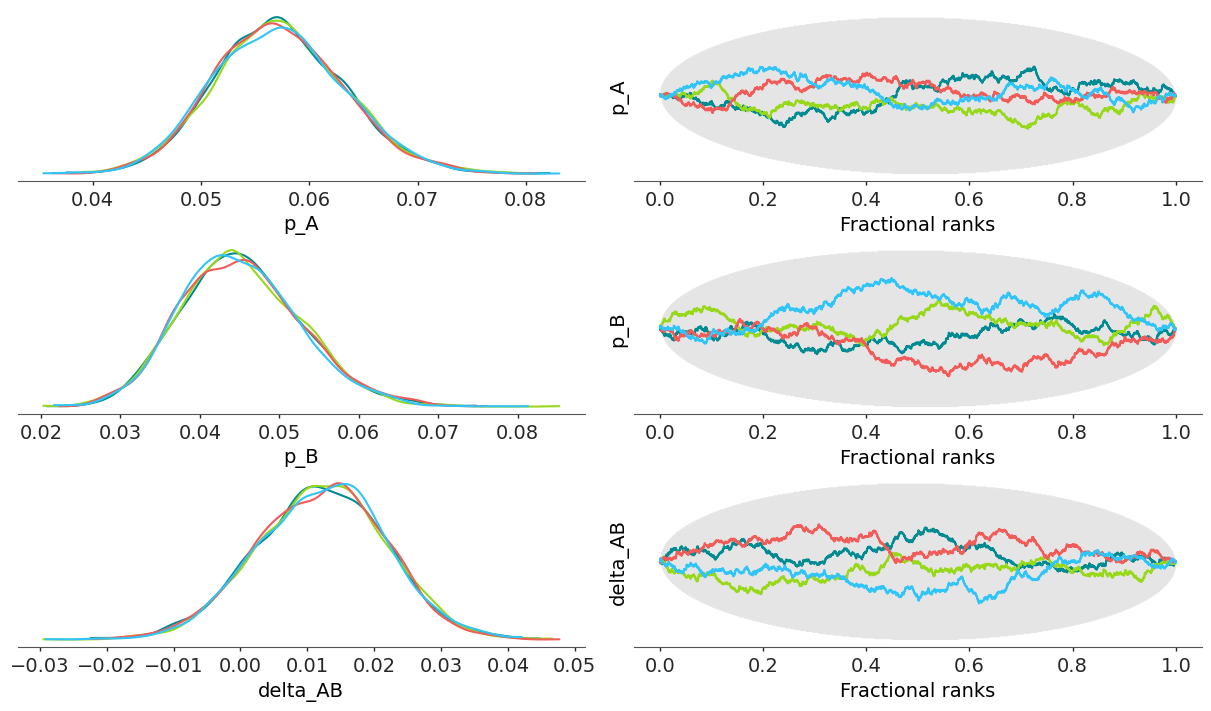

In [13]:
# Plot traces for convergence checking
az.plot_rank_dist(
    dt=idata_ab,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (12, 7)},
);

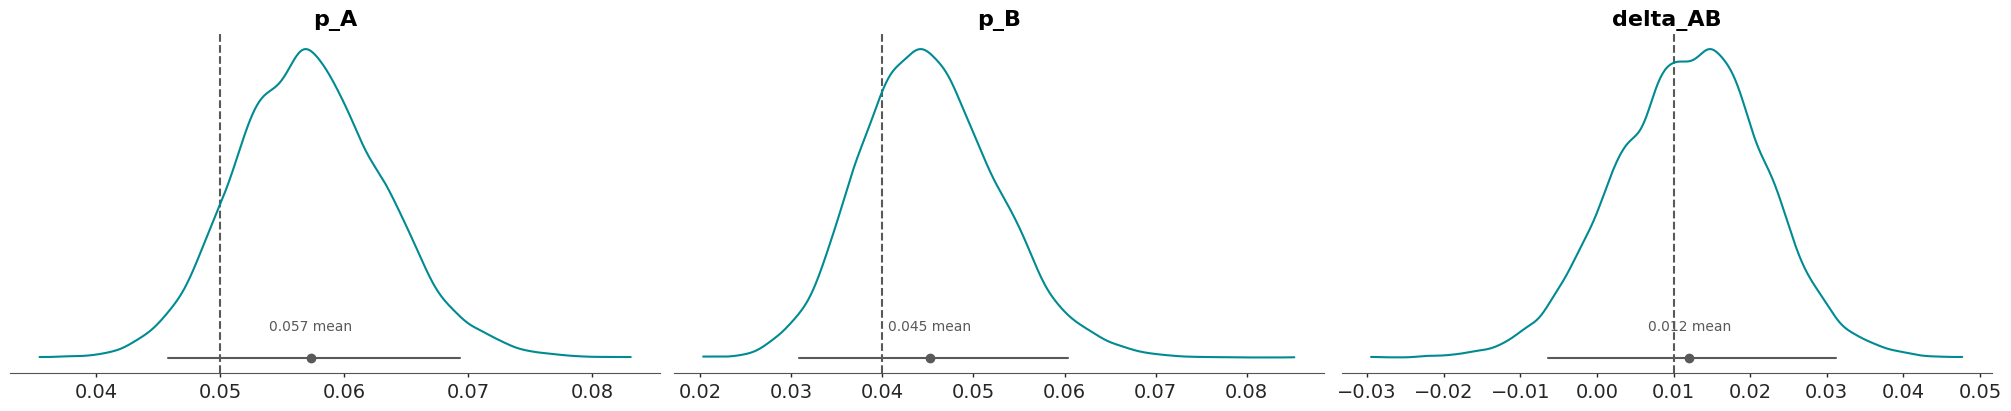

In [14]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_ab,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 4)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "p_A": true_p_A,
        "p_B": true_p_B,
        "delta_AB": true_p_A - true_p_B,
    },
    orientation="vertical"
);

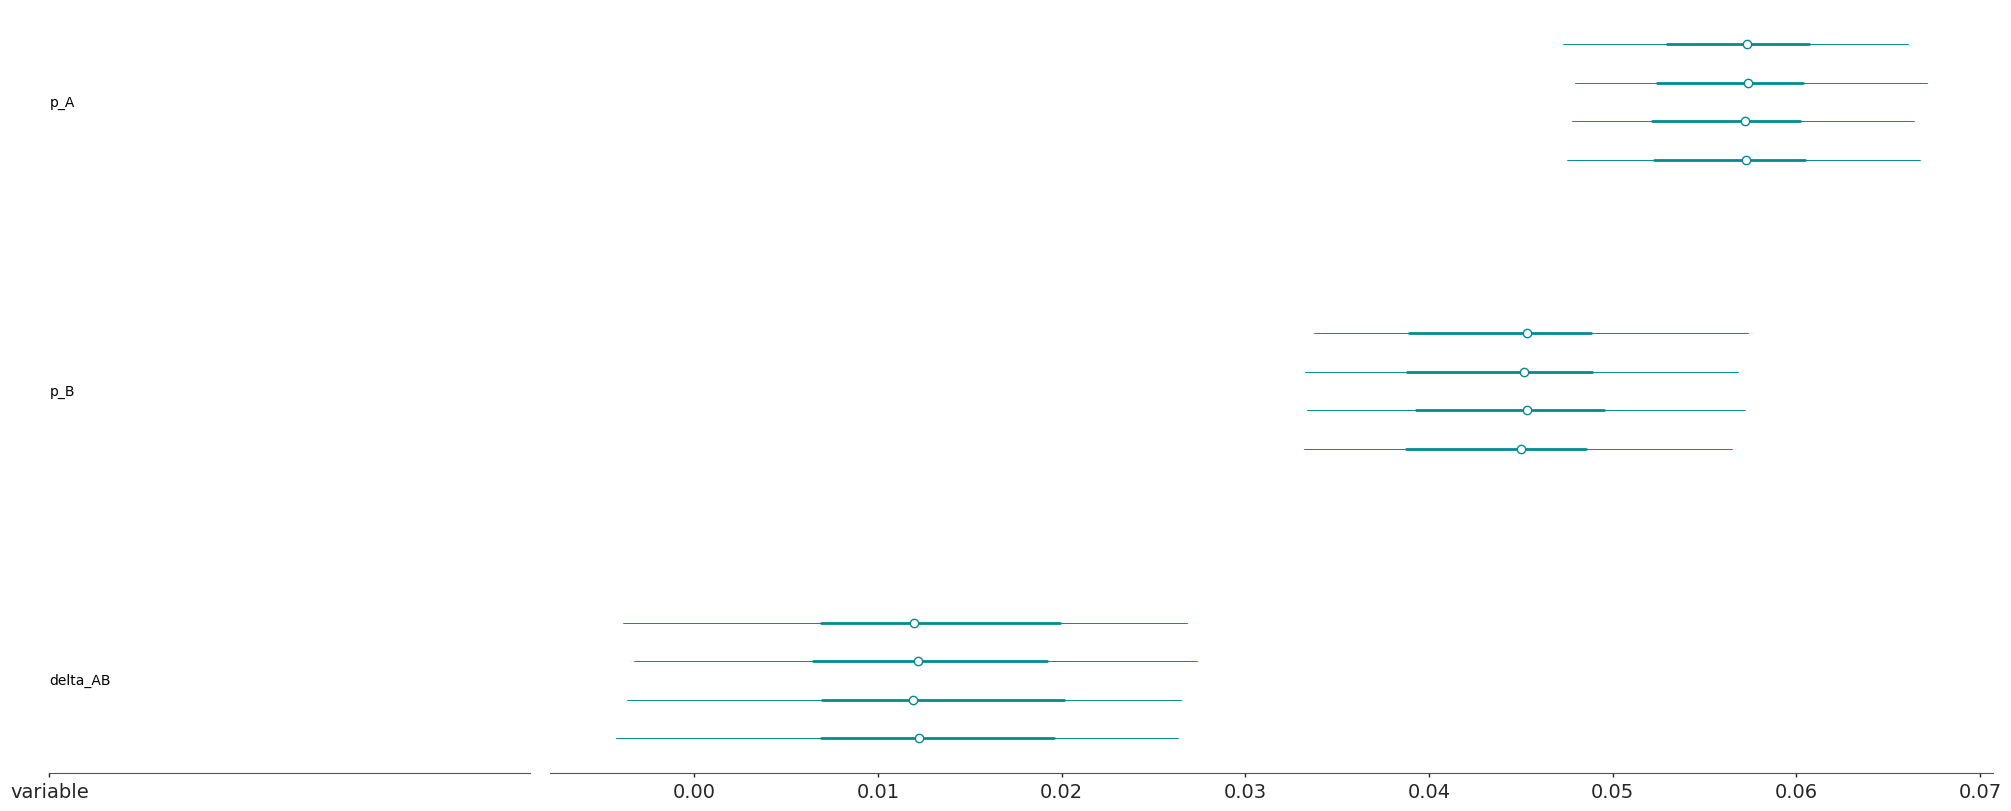

In [15]:
# Plot results
az.plot_forest(
    dt=idata_ab, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    combined=False, point_estimate="mean", ci_kind="hdi", ci_probs=None,
    labels=None, stats=None,
    figure_kwargs={"figsize": (20, 8)},
);

In [22]:
# Get AB metric
print(f"Probability of B being better than A: {(idata_ab.posterior["p_B"] > idata_ab.posterior["p_A"]).mean():.3f}")

Probability of B being better than A: 0.109


# `A/B` DATA

In [77]:
# Define variables related to collected data
visitors_to_A = 1300
visitors_to_B = 1275

conversions_from_A = 120
conversions_from_B = 125

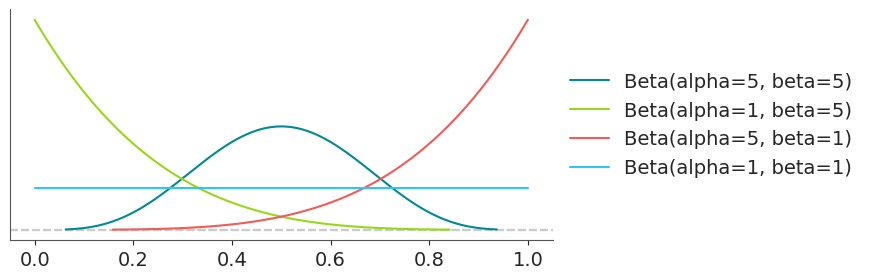

In [78]:
##########################
######### PRIORS #########

pz.Beta(alpha=5, beta=5).plot_pdf(figsize=(7, 3))
pz.Beta(alpha=1, beta=5).plot_pdf()
pz.Beta(alpha=5, beta=1).plot_pdf()
pz.Beta(alpha=1, beta=1).plot_pdf()
plt.show()

**Conjugate distributions**:

https://en.wikipedia.org/wiki/Conjugate_prior

In [79]:
# Prior -> probability of conversion between 0 and 1
#   prior Beta
# Likelihood -> number of conversions (successes) given number of visits (trials)
#   likelihood Binomial
# Conjugate distributions
#   prior = Beta and likelihood = Bernoulli

Probab of B is better than A: 69.03


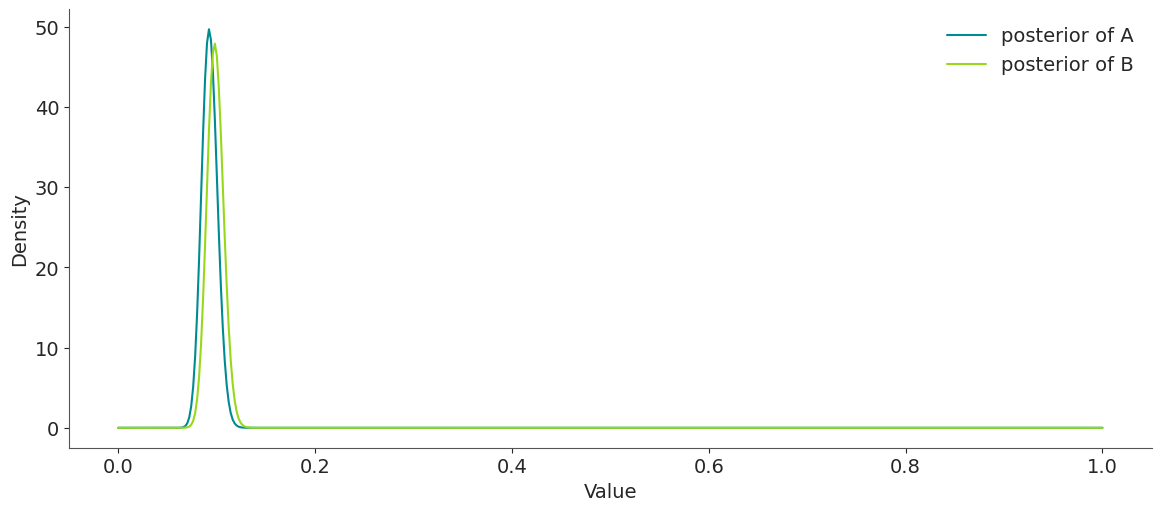

In [80]:
##########################
######### Priors #########
alpha_prior = 1
beta_prior = 1


##############################
######### POSTERIORS #########
posterior_A = beta(
    alpha_prior + conversions_from_A,
    beta_prior + (visitors_to_A - conversions_from_A)
)
posterior_B = beta(
    alpha_prior + conversions_from_B,
    beta_prior + (visitors_to_B - conversions_from_B)
)


###########################################
######### SAMPLING FROM POSTERIOR #########
samples = 20_000 # We want this to be large to get a better approximation.
samples_posterior_A = posterior_A.rvs(samples)
samples_posterior_B = posterior_B.rvs(samples)
print(
    f"Probab of B is better than A: {(samples_posterior_B > samples_posterior_A).mean() * 100:.2f}"
)

# Plot
x = np.linspace(start=0, stop=1, num=500)
plt.plot(x, posterior_A.pdf(x), label='posterior of A')
plt.plot(x, posterior_B.pdf(x), label='posterior of B')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

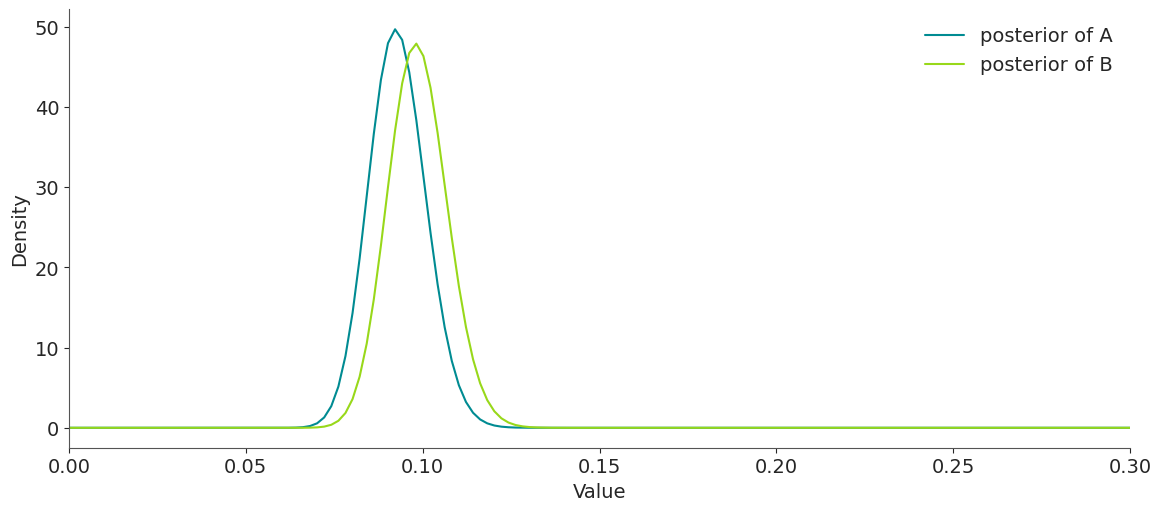

In [84]:
# Plot
x = np.linspace(start=0, stop=1, num=500)
plt.plot(x, posterior_A.pdf(x), label='posterior of A')
plt.plot(x, posterior_B.pdf(x), label='posterior of B')
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(0, 0.3)
plt.legend()
plt.show()

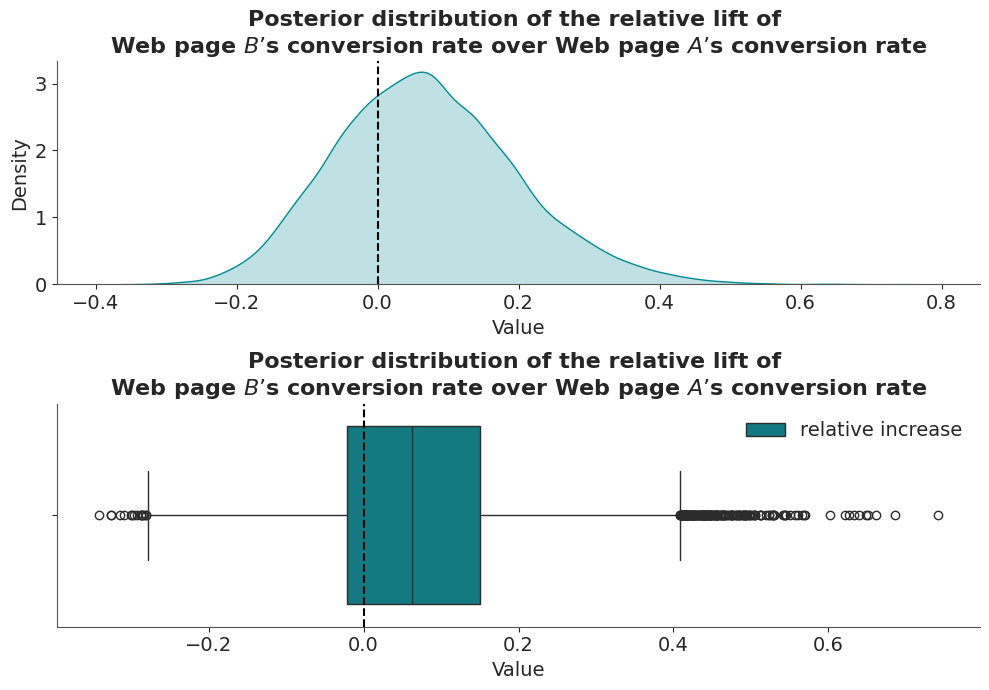

[-0.12940849 -0.02106076  0.06278444  0.15061065  0.29597091]


In [91]:
# Calculate relative increase with distributions
def relative_increase(a, b):
    return ( a - b ) / b

# Calculate relative increase
posterior_relative_increase = relative_increase(samples_posterior_B, samples_posterior_A)
# Plot
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), tight_layout=True)
idx=0
sns.kdeplot(
    x=posterior_relative_increase, label="relative increase", fill=True, ax=axs[idx]
)
axs[idx].set_title("Posterior distribution of the relative lift of \nWeb page $B$’s conversion rate over Web page $A$’s conversion rate")
axs[idx].set_xlabel('Value')
axs[idx].set_ylabel('Density')
axs[idx].axvline(0, color="black", linestyle="--")
idx=1
sns.boxplot(
    x=posterior_relative_increase, label="relative increase", ax=axs[idx]
)
axs[idx].set_title("Posterior distribution of the relative lift of \nWeb page $B$’s conversion rate over Web page $A$’s conversion rate")
axs[idx].set_xlabel('Value')
axs[idx].axvline(0, color="black", linestyle="--")
plt.show()

print(np.quantile(a=posterior_relative_increase, q=[0.05, 0.25, 0.50, 0.75, 0.95]))

**Expected Revenue** = 79 * p_79 + 49 * p_49 + 25 * p_25 + 0 * p_0

<u>Probabilities are correlated as they must sum to 1 -> can not use Beta or Binomial -> has to model all the probabilities
together.</u>

In [ ]:
# Prior -> probability of conversion between 0 and 1, all summing up to 1
#   prior Dirichlet (generalization of Beta)
# Likelihood -> number of conversions (successes) given number of visits (trials)
#   likelihood Multinomial (generalization of Bernoulli)
# Conjugate distributions
#   prior = Dirichlet and likelihood = Multinomial

In [15]:
# Sample from multinomial - generalization of Binomial -> positive vertors that sums to 1
P = [0.5, 0.2, 0.3]
N = 1
multinomial(
    n=N, # Number of experiments
    pvals=[0.5, 0.2, 0.3]  # Probabilities of each of the p different outcomes. These must sum to 1
)

array([0, 1, 0])

In [22]:

# Sample from Dirichlet -> generalization of Beta -> positive vectors that sums to 1
# alpha shape determines the number of categories (K = len(alpha)).
# Each row sums to 1 — it's a distribution over the simplex.
# Effect of alpha values:
#       All alpha_i = 1 → uniform over the simplex (no preference).
#       alpha_i < 1 → mass pushed toward corners/edges (sparse, one component dominates).
#       alpha_i > 1 → mass pushed toward the center (more even splits).
#       Larger alpha_i relative to others → that category gets more weight on average (mean is alpha / alpha.sum())
alpha=[1, 1, 1]
dirichlet(
    alpha=alpha
) 

array([0.01194653, 0.20613552, 0.78191795])

In [23]:
# Define observed data
N = 1000                        # total people
N_79 = 10                       # people that subscribed to $ 79 plan
N_49 = 46                       # people that subscribed to $ 79 plan
N_25 = 80                       # people that subscribed to $ 79 plan
N_0 = N - (N_79 + N_49 + N_49)  # people that subscribed to no plan
# Define observations
observations = np.array([N_79, N_49, N_25, N_0])
observations

array([ 10,  46,  80, 898])

Example of sample: [0.00953083 0.05250524 0.07058777 0.86737616]


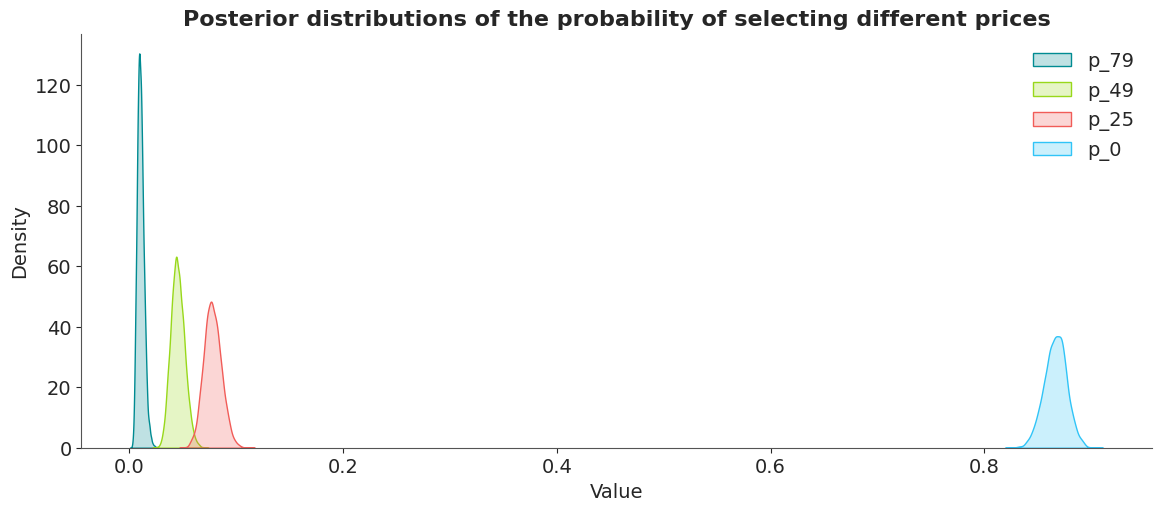

In [ ]:
##########################
######### Priors #########
# Define prior for subscribing plans
prior_parameters = np.array([1, 1, 1, 1])

##############################
######### POSTERIORS #########
# Dirichlet(1 + N_1 , 1 + N_2 , ..., 1 + N_m)
posterior_samples = dirichlet(
    alpha=prior_parameters + observations,
    size=10_000
)
# Inspecting samples
print(f"Example of sample: {posterior_samples[9]}")

# Plot
for i, label in enumerate(['p_79', 'p_49', 'p_25', 'p_0']):
    sns.kdeplot(
        x=posterior_samples[:, i], label=label, fill=True
    )
plt.xlabel('Value')
plt.ylabel('Density')
plt.title("Posterior distributions of the probability of selecting different prices")
plt.legend()
plt.show()

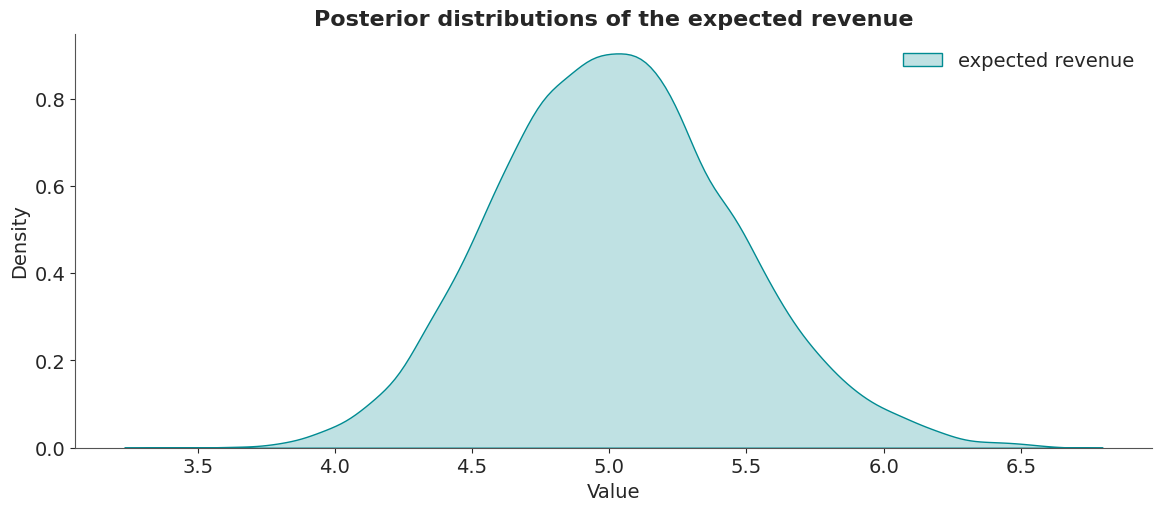

In [30]:
def expected_revenue(P):
    "Function to calculate expected revenue over samples"
    return 79*P[:,0] + 49*P[:,1] + 25*P[:,2] + 0*P[:,3]

# Get expected revenue
posterior_expected_revenue = expected_revenue(posterior_samples)
sns.kdeplot(x=posterior_expected_revenue, fill=True, label='expected revenue')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title("Posterior distributions of the expected revenue")
plt.legend()
plt.show()

In [33]:
# Simulate data for site A and B
N_A = 1000
N_A_79 = 10
N_A_49 = 46
N_A_25 = 80
N_A_0 = N_A - (N_A_79 + N_A_49 + N_A_49)
N_B = 2000
N_B_79 = 45
N_B_49 = 84
N_B_25 = 200
N_B_0 = N_B - (N_B_79 + N_B_49 + N_B_49)
observations_A = np.array([N_A_79, N_A_49, N_A_25, N_A_0])
observations_B = np.array([N_B_79, N_B_49, N_B_25, N_B_0])

Example of sample from site A: [0.01486338 0.04675037 0.06929921 0.86908704]
Example of sample from site B: [0.01714519 0.04352937 0.08921471 0.85011073]


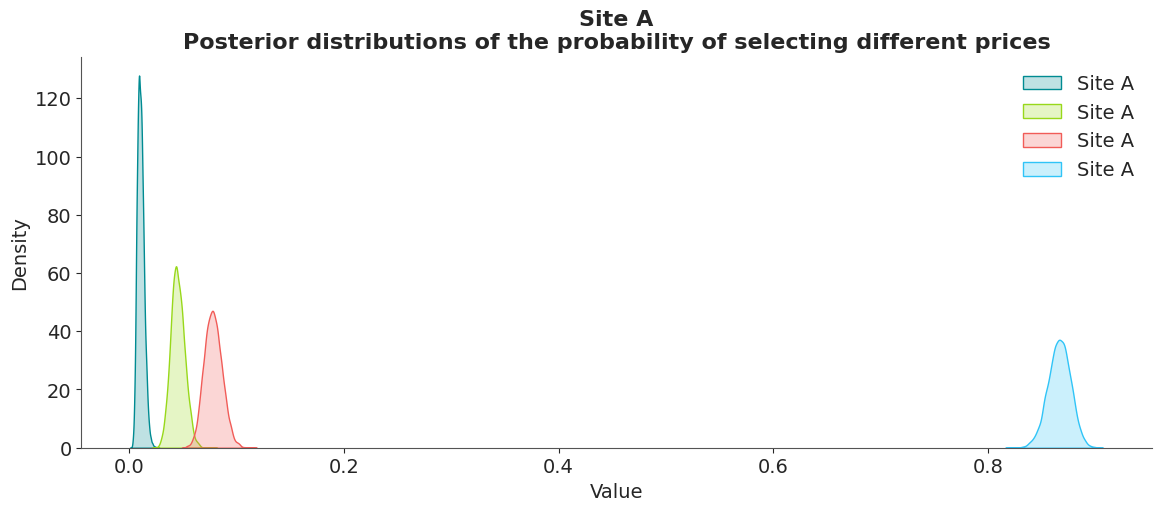

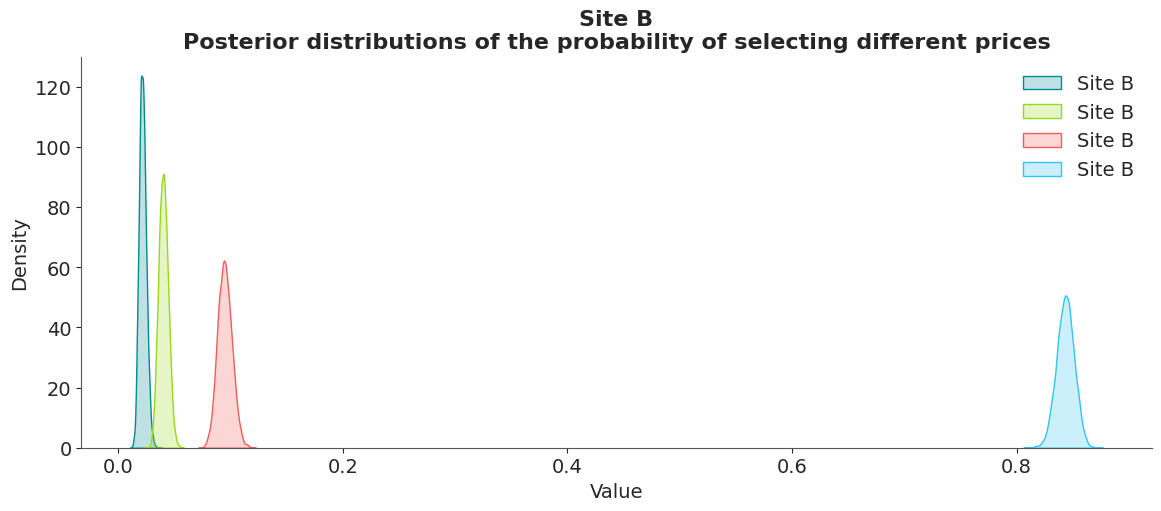

In [36]:
##########################
######### Priors #########
# Define prior for subscribing plans
prior_parameters = np.array([1, 1, 1, 1])

##############################
######### POSTERIORS #########
# Dirichlet(1 + N_1 , 1 + N_2 , ..., 1 + N_m)
posterior_samples_A = dirichlet(
    alpha=prior_parameters + observations_A,
    size=10000
)
posterior_samples_B = dirichlet(
    alpha=prior_parameters + observations_B,
    size=10000
)
# Inspecting samples
print(f"Example of sample from site A: {posterior_samples_A[9]}")
print(f"Example of sample from site B: {posterior_samples_B[9]}")


# Iterate over sites
for posterior_sample_site, site_label in [(posterior_samples_A, "Site A"), (posterior_samples_B, "Site B")]:
    # Plot
    for i, label in enumerate(['p_79', 'p_49', 'p_25', 'p_0']):
        sns.kdeplot(
            x=posterior_sample_site[:, i], label=site_label, fill=True
        )
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title(f"{site_label}\nPosterior distributions of the probability of selecting different prices")
    plt.legend()
    plt.show()

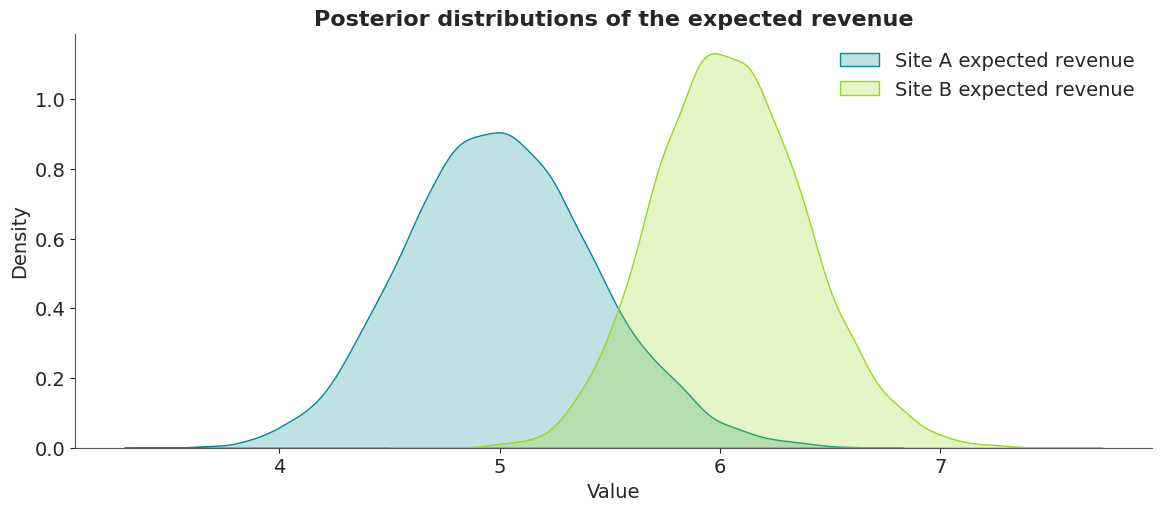

In [37]:

# Get expected revenue
posterior_expected_revenue_A = expected_revenue(posterior_samples_A)
posterior_expected_revenue_B = expected_revenue(posterior_samples_B)
ax = sns.kdeplot(x=posterior_expected_revenue_A, fill=True, label="Site A expected revenue")
sns.kdeplot(x=posterior_expected_revenue_B, fill=True, label="Site B expected revenue", ax=ax)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title("Posterior distributions of the expected revenue")
plt.legend()
plt.show()

In [38]:
# Print report
print(f"Probability that page B has a higher revenue than page A: {(posterior_expected_revenue_B > posterior_expected_revenue_A).mean():.3f}")

Probability that page B has a higher revenue than page A: 0.969


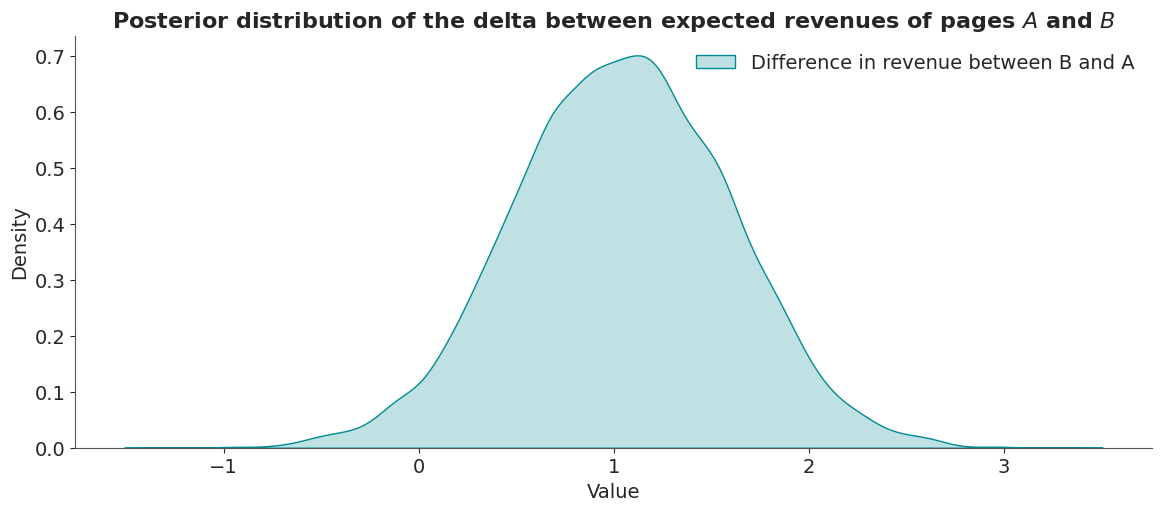

In [39]:

# Get expected revenue difference
sns.kdeplot(
    x=posterior_expected_revenue_B - posterior_expected_revenue_A, fill=True,
    label="Difference in revenue between B and A"
)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Posterior distribution of the delta between expected revenues of pages $A$ and $B$')
plt.legend()
plt.show()

**BEST (Bayesian Estimation Supersedes the t-test)**

In [44]:
# Simulate data
N = 250
mu_A, std_A = 30, 4
mu_B, std_B = 26, 7

# Create durations (seconds) users are on the pages for
durations_A = np.random.normal(mu_A, std_A, size=N)
durations_B = np.random.normal(mu_B, std_B, size=N)

# Print samples
print(f"First 10 samples from A: {durations_A[:10]}")
print(f"First 10 samples from B: {durations_B[:10]}")

First 10 samples from A: [28.95741288 30.20339637 28.24757833 32.62907055 35.16657458 32.8262679
 26.17515467 31.40341176 36.44534724 29.736512  ]
First 10 samples from B: [12.76293405 22.13959123 23.65773974 29.98863907 24.01550678 22.31393031
 32.51364401 26.51435161 34.30915748 30.19784918]


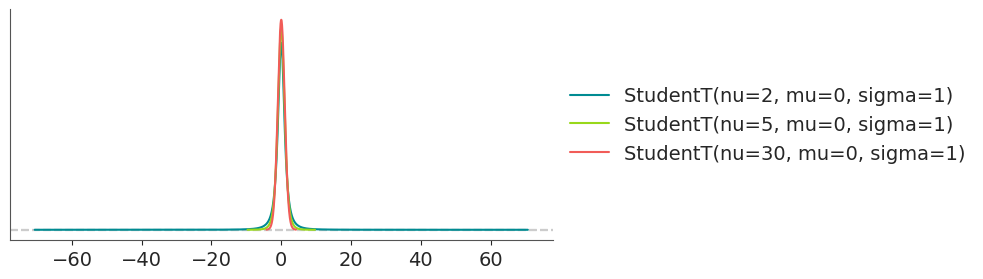

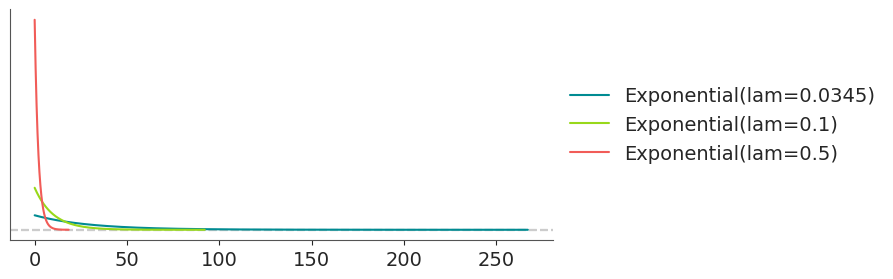

In [55]:
##########################
######### PRIORS #########

pz.StudentT(nu=2, mu=0, sigma=1).plot_pdf(figsize=(7, 3))
pz.StudentT(nu=5, mu=0, sigma=1).plot_pdf(figsize=(7, 3))
pz.StudentT(nu=30, mu=0, sigma=1).plot_pdf(figsize=(7, 3))
plt.show()

pz.Exponential(lam=1/29).plot_pdf(figsize=(7, 3))
pz.Exponential(lam=0.1).plot_pdf(figsize=(7, 3))
pz.Exponential(lam=0.5).plot_pdf(figsize=(7, 3))
plt.show()

In [63]:
# According to the BEST model (Bayesian Estimation Supersedes the t-test), our priors for the unknowns are as follows.
with pm.Model() as model_best:
    #########################
    ######### PRIORS ########
    # μA and μB come from a Normal distribution with prior mean equal to the pooled mean of data from A and B,
    # and prior standard deviation equal to 1,000 times the pooled standard deviation.
    # (This is a very wide, uniformative prior.)
    pooled = np.concatenate([durations_A, durations_B])
    pooled_mean = pooled.mean()
    pooled_std = pooled.std(ddof=1)
    mu_A = pm.Normal(name="mu_A", mu=pooled_mean, sigma=1_000 * pooled_std)
    mu_B = pm.Normal(name="mu_B", mu=pooled_mean, sigma=1_000 * pooled_std)

    # σA and σB come from a uniform distribution,
    # restricted to one one-thousandths of the pooled standard deviation, to 1000 times the standard deviation.
    # (Again, a very wide uninformative prior).
    std_A = pm.Uniform(name="std_A", lower=pooled_std / 1_000, upper=pooled_std * 1_000)
    std_B = pm.Uniform(name="std_B", lower=pooled_std / 1_000, upper=pooled_std * 1_000)

    # Finally, ν is estimated from a shifted exponential distribution with parameter equal to 29.
    # For more details about why this was chosen, it is detailed in Appendix A of [1].
    # One interesting detail of BEST is that ν is shared between the two groups. 
    # This will be clearer in the following diagram.
    nu_minus_1 = pm.Exponential("nu_minus_1", 1./29)


    ##############################
    ######### LIKELIHOOD #########
    # pm.Deterministic
    #   It doesn't change the model's inference at all — it's purely bookkeeping.
    #   It wraps an expression so PyMC (a) gives it a name and (b) stores its value at every posterior draw in the resulting InferenceData.
    diff_of_means = pm.Deterministic(name="difference_of_means", var=mu_A - mu_B)
    diff_of_stds = pm.Deterministic(name="difference_of_stds", var=std_A - std_B)
    effect_size = pm.Deterministic(
        name="effect_size", var=diff_of_means / pm.math.sqrt((std_A**2 + std_B**2) / 2)
    )
    obs_A = pm.StudentT(
        name="obs_A", mu=mu_A, sigma=std_A, nu=nu_minus_1 + 1, observed=durations_A
    )
    obs_B = pm.StudentT(
        name="obs_B", mu=mu_B, sigma=std_B, nu=nu_minus_1 + 1, observed=durations_B
    )
    # MCMC sampling
    idata_ab = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=4_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
    )

    pm.compute_log_likelihood(
        idata=idata_ab, extend_inferencedata=True
    )


# Save a checkpoint
idata_ab.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_ab.nc")
)

# Inspect idata
idata_ab

NUTS[nutpie]: [mu_A, mu_B, std_A, std_B, nu_minus_1]


Output()

Output()

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:              (chain: 4, draw: 4000)
│       Coordinates:
│         * chain                (chain) int64 32B 0 1 2 3
│         * draw                 (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
│       Data variables:
│           mu_A                 (chain, draw) float64 128kB 30.24 29.86 ... 30.31 29.97
│           mu_B                 (chain, draw) float64 128kB 26.01 26.27 ... 26.21 26.39
│           std_A                (chain, draw) float64 128kB 3.522 3.83 ... 3.587 3.595
│           std_B                (chain, draw) float64 128kB 7.132 7.337 ... 6.978 7.068
│           nu_minus_1           (chain, draw) float64 128kB 27.72 21.53 ... 11.77 40.48
│           difference_of_means  (chain, draw) float64 128kB 4.232 3.592 ... 4.105 3.578
│           difference_of_stds   (chain, draw) float64 128kB -3.61 -3.507 ... -3.473
│           effect_size          (chain, draw) float64 128kB 0.7525 0.6137 ... 0.6381
│       Attributes:
│           created_at:                 2026-07-28T18:47:24.258701+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.4563908576965332
│           tuning_steps:               4000
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 4000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 32kB 0 1 2 3 ... 3996 3997 3998 3999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 128kB 2 2 2 2 2 ... 2 2 2 2 2
│           maxdepth_reached          (chain, draw) bool 16kB False False ... False
│           step_size                 (chain, draw) float64 128kB 0.968 0.8408 ... 0.866
│           transformation_update_id  (chain, draw) int64 128kB 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 128kB 0.8949 ... 0.9143
│           mean_tree_accept          (chain, draw) float64 128kB 0.9947 0.5613 ... 1.0
│           ...                        ...
│           fisher_distance           (chain, draw) float64 128kB 0.3171 ... 0.09788
│           transformation_index      (chain, draw) int64 128kB 3398 3398 ... 3396 3396
│           diverging                 (chain, draw) bool 16kB False False ... False
│           divergence_draw           (chain, draw) uint64 128kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 128kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 128kB nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-07-28T18:47:24.249747+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.1.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-07-28T18:47:24.255679+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
├── Group: /observed_data
│       Dimensions:      (obs_A_dim_0: 250, obs_B_dim_0: 250)
│       Coordinates:
│         * obs_A_dim_0  (obs_A_dim_0) int64 2kB 0 1 2 3 4 5 ... 244 245 246 247 248 249
│         * obs_B_dim_0  (obs_B_dim_0) int64 2kB 0 1 2 3 4 5 ... 

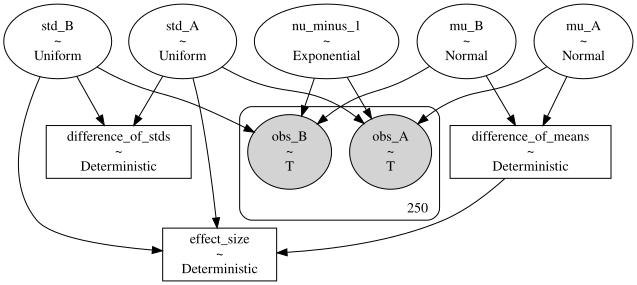

In [64]:
# plot graph
model_best.to_graphviz()

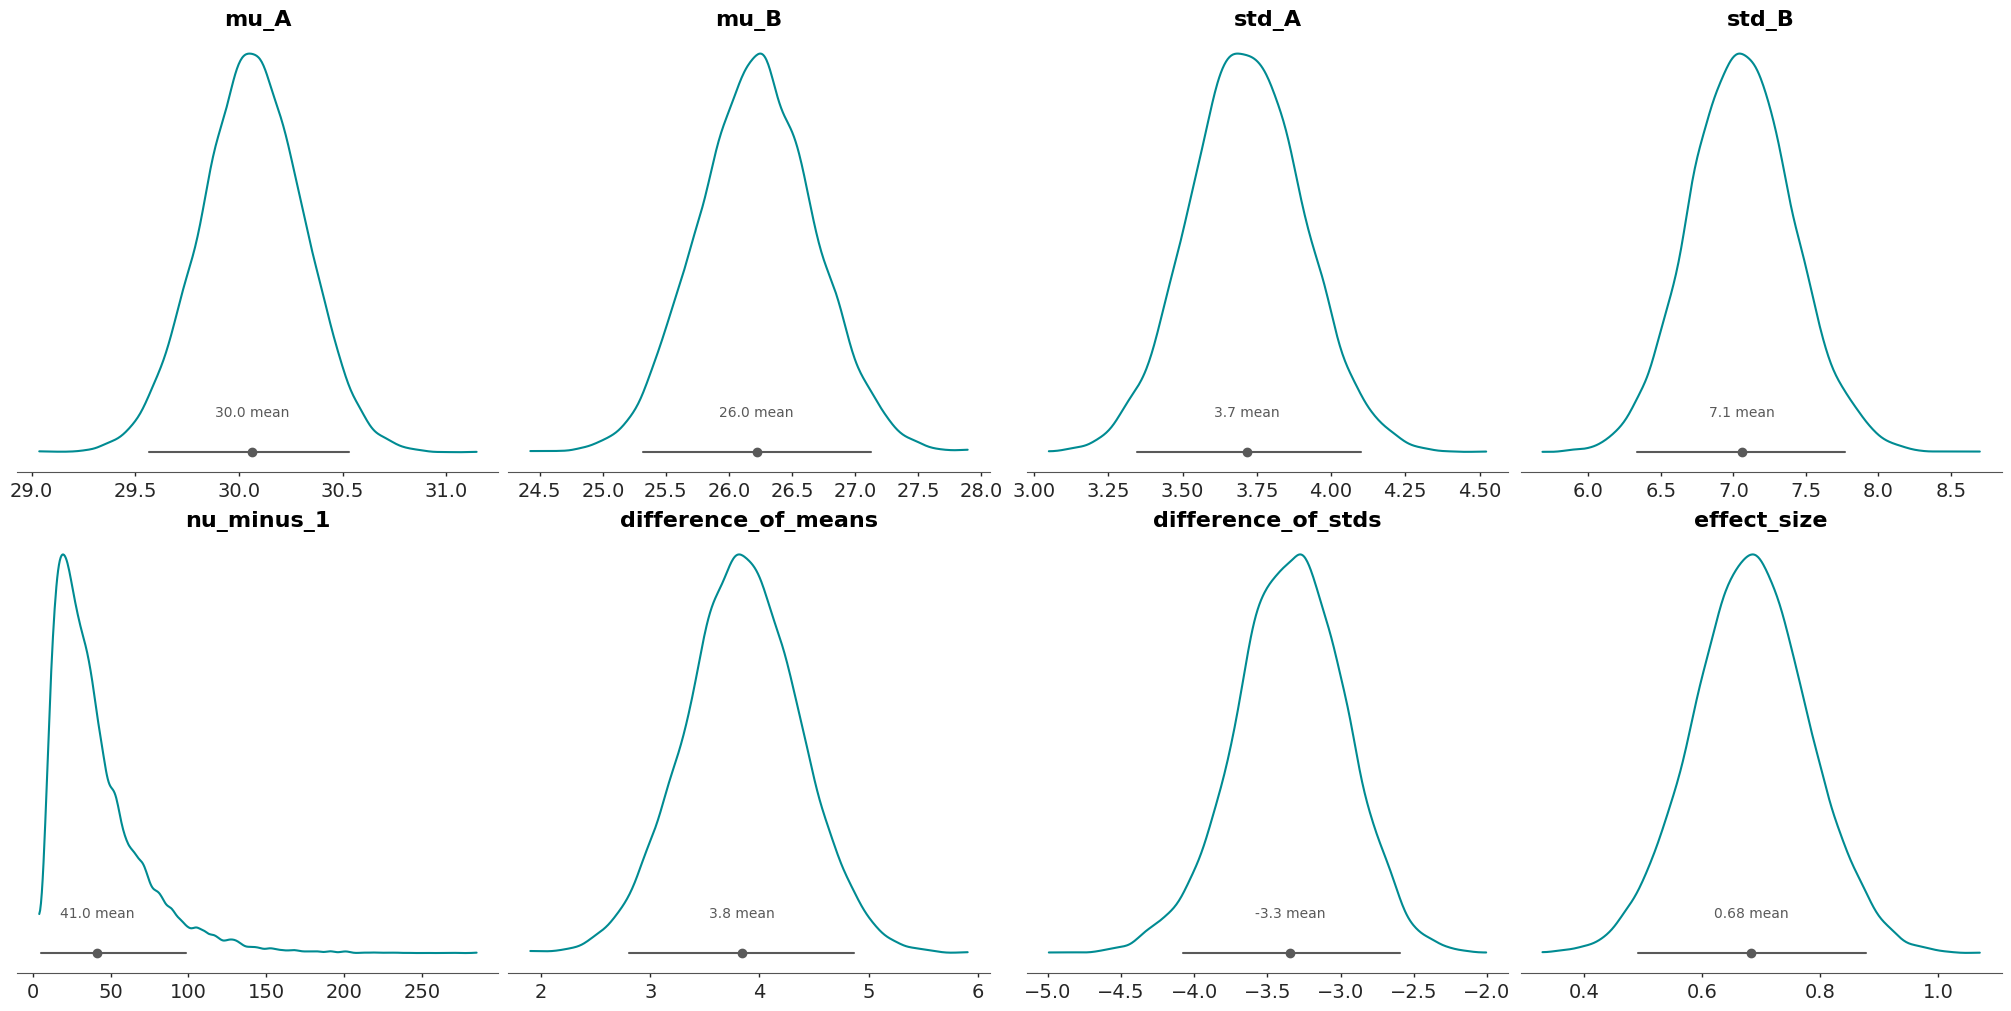

In [66]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_ab,
    var_names=None,
    filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 10)},
)

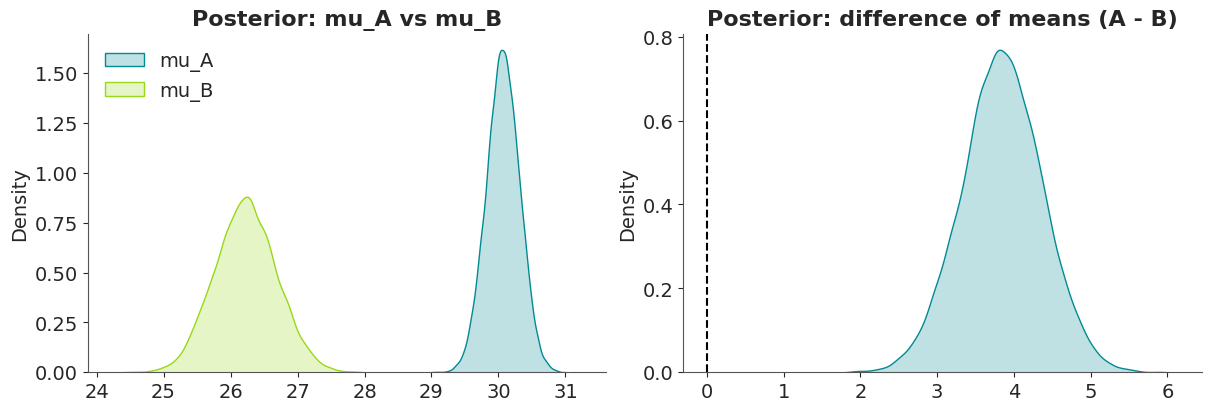

In [75]:
# Get posteriors
mu_A = idata_ab.posterior["mu_A"].values.flatten()
mu_B = idata_ab.posterior["mu_B"].values.flatten()
diff = idata_ab.posterior["difference_of_means"].values.flatten()

# Plot
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
sns.kdeplot(mu_A, fill=True, label="mu_A", ax=axs[0])
sns.kdeplot(mu_B, fill=True, label="mu_B", ax=axs[0])
axs[0].set_title("Posterior: mu_A vs mu_B")
axs[0].legend()
sns.kdeplot(diff, fill=True, label="A - B", ax=axs[1])
axs[1].set_title("Posterior: difference of means (A - B)")
axs[1].axvline(0, color="black", linestyle="--")
axs[0].legend()
plt.show()

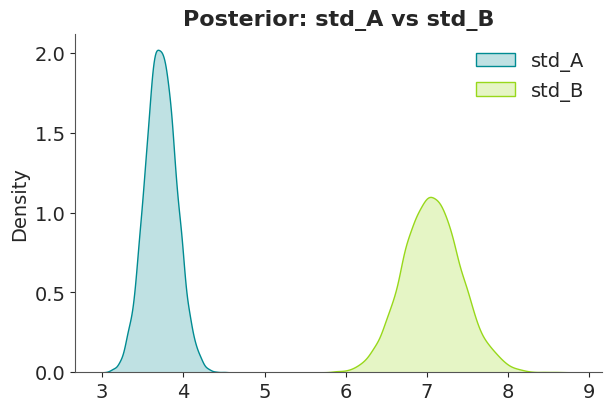

In [76]:
# Get posteriors
std_A = idata_ab.posterior["std_A"].values.flatten()
std_B = idata_ab.posterior["std_B"].values.flatten()

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(std_A, fill=True, label="std_A", ax=ax)
sns.kdeplot(std_B, fill=True, label="std_B", ax=ax)
ax.legend()
ax.set_title("Posterior: std_A vs std_B")
plt.show()